# 05 — Robot Exit Parameter Analysis

Sinyal parametreleri baseline değerlerinde sabit tutulur:

- Buy score: 11
- Minimum ADX: 20
- Volume multiplier: 1.30

Bu notebook yalnızca stop ve trailing parametrelerini geliştirme döneminde test eder.
Holdout dönemi parametre seçiminde kullanılmaz.


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = (
    Path.cwd()
    if (Path.cwd() / "src").exists()
    else Path.cwd().parent
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%load_ext autoreload
%autoreload 2

from src.config import StrategyConfig, PortfolioConfig
from src.features import add_indicators
from src.signals import build_market_regime
from src.experiments import (
    run_strategy_grid,
    apply_robustness_filters,
    compare_periods,
)

sns.set_theme(style="whitegrid")


c:\Users\okand\Desktop\Projects\Algorithmic Trading\BIST-Algo-Trade\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Verileri ve özellikleri hazırla


In [2]:
stock_prices = pd.read_parquet(
    PROJECT_ROOT
    / "data"
    / "processed"
    / "bist100_robot_clean.parquet"
)

market_prices = pd.read_parquet(
    PROJECT_ROOT
    / "data"
    / "processed"
    / "xu100_robot_clean.parquet"
)

stock_features = add_indicators(stock_prices)
market_features = add_indicators(market_prices)
market_regime = build_market_regime(market_features)

PERIODS = {
    "Development": ("2018-01-01", "2022-12-31"),
    "Validation": ("2023-01-01", "2024-12-31"),
    "Holdout": (
        "2025-01-01",
        stock_features["Date"].max().strftime("%Y-%m-%d"),
    ),
}

base_strategy = StrategyConfig(
    buy_score=12,
    minimum_adx=18.0,
    volume_multiplier=1.3,
)

base_portfolio = PortfolioConfig()

print("Hisse özellikleri:", stock_features.shape)
print("Tarih:", stock_features["Date"].min(), "→", stock_features["Date"].max())


Hisse özellikleri: (152459, 42)
Tarih: 2018-10-18 00:00:00 → 2026-07-24 00:00:00


## 2. Çıkış parametre grid'i

İlk aşamada 27 kombinasyon test edilir:

- Initial stop: 1.5 / 2.0 / 2.5 ATR
- Trailing stop: 2.0 / 2.5 / 3.0 ATR
- Trailing aktivasyonu: %4 / %6 / %8

Risk, komisyon, slippage ve giriş sinyalleri sabittir.


In [3]:
exit_grid = {
    "initial_stop_atr": [1.5, 2.0, 2.5],
    "trailing_stop_atr": [2.0, 2.5, 3.0],
    "trailing_activation_return": [0.04, 0.06, 0.08],
}

exit_development_results = run_strategy_grid(
    stock_features=stock_features,
    market_regime=market_regime,
    base_strategy=base_strategy,
    portfolio_config=base_portfolio,
    parameter_grid=exit_grid,
    start=PERIODS["Development"][0],
    end=PERIODS["Development"][1],
)

RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

exit_development_results.to_csv(
    RESULTS_DIR / "exit_grid_development.csv",
    index=False,
)

print("Deney sayısı:", len(exit_development_results))


Strateji grid: 2018-01-01 → 2022-12-31: 100%|██████████| 27/27 [03:31<00:00,  7.85s/it]

Deney sayısı: 27


## 3. Geliştirme döneminde dayanıklılık filtreleri


In [4]:
robust_exit_development = apply_robustness_filters(
    exit_development_results,
    minimum_trades=150,
    maximum_drawdown_limit=-35.0,
    minimum_profit_factor=1.20,
)

exit_columns = [
    "Experiment_ID",
    "Strategy_initial_stop_atr",
    "Strategy_trailing_stop_atr",
    "Strategy_trailing_activation_return",
    "CAGR_%",
    "Max_Drawdown_%",
    "Profit_Factor",
    "Sharpe",
    "Calmar",
    "Trade_Count",
]

display(
    robust_exit_development[exit_columns].head(15)
)


,Experiment_ID,Strategy_initial_stop_atr,Strategy_trailing_stop_atr,Strategy_trailing_activation_return,CAGR_%,Max_Drawdown_%,Profit_Factor,Sharpe,Calmar,Trade_Count
0,14,2.0,2.5,0.06,60.984835,-21.036353,2.639109,2.580370,2.899021,396
1,17,2.0,3.0,0.06,63.625537,-22.110906,2.940926,2.624161,2.877564,353
2,16,2.0,3.0,0.04,63.455842,-22.077770,2.939071,2.603837,2.874196,355
3,18,2.0,3.0,0.08,64.417105,-22.710551,2.979130,2.637282,2.836439,349
4,8,1.5,3.0,0.06,72.360706,-26.257333,2.678658,2.488668,2.755828,420
5,25,2.5,3.0,0.04,49.819477,-18.128948,2.903048,2.509851,2.748062,337
6,9,1.5,3.0,0.08,68.666436,-25.460622,2.647442,2.395279,2.696966,416
7,26,2.5,3.0,0.06,49.502989,-18.612252,2.884099,2.505380,2.659699,337
8,3,1.5,2.0,0.08,74.838032,-28.230846,2.219082,2.554548,2.650931,539
9,6,1.5,2.5,0.08,74.611815,-29.121181,2.535500,2.496198,2.562115,458


## 4. Baseline dahil en iyi adayları doğrulama dönemine taşı

Baseline kombinasyonu:

- Initial stop: 2 ATR
- Trailing stop: 2.5 ATR
- Aktivasyon: %6


In [5]:
baseline_mask = (
    exit_development_results["Strategy_initial_stop_atr"].eq(2.0)
    & exit_development_results["Strategy_trailing_stop_atr"].eq(2.5)
    & exit_development_results[
        "Strategy_trailing_activation_return"
    ].eq(0.06)
)

baseline_exit_row = exit_development_results.loc[
    baseline_mask
].copy()

selected_exit_development = (
    pd.concat(
        [
            robust_exit_development.head(8),
            baseline_exit_row,
        ],
        ignore_index=True,
    )
    .drop_duplicates(
        subset=[
            "Strategy_initial_stop_atr",
            "Strategy_trailing_stop_atr",
            "Strategy_trailing_activation_return",
        ]
    )
    .reset_index(drop=True)
)

display(selected_exit_development[exit_columns])


,Experiment_ID,Strategy_initial_stop_atr,Strategy_trailing_stop_atr,Strategy_trailing_activation_return,CAGR_%,Max_Drawdown_%,Profit_Factor,Sharpe,Calmar,Trade_Count
0,14,2.0,2.5,0.06,60.984835,-21.036353,2.639109,2.580370,2.899021,396
1,17,2.0,3.0,0.06,63.625537,-22.110906,2.940926,2.624161,2.877564,353
2,16,2.0,3.0,0.04,63.455842,-22.077770,2.939071,2.603837,2.874196,355
3,18,2.0,3.0,0.08,64.417105,-22.710551,2.979130,2.637282,2.836439,349
4,8,1.5,3.0,0.06,72.360706,-26.257333,2.678658,2.488668,2.755828,420
5,25,2.5,3.0,0.04,49.819477,-18.128948,2.903048,2.509851,2.748062,337
6,9,1.5,3.0,0.08,68.666436,-25.460622,2.647442,2.395279,2.696966,416
7,26,2.5,3.0,0.06,49.502989,-18.612252,2.884099,2.505380,2.659699,337


In [6]:
exit_parameter_columns = [
    "Strategy_initial_stop_atr",
    "Strategy_trailing_stop_atr",
    "Strategy_trailing_activation_return",
]

exit_comparison = compare_periods(
    stock_features=stock_features,
    market_regime=market_regime,
    configurations=selected_exit_development,
    base_strategy=base_strategy,
    portfolio_config=base_portfolio,
    periods={
        "Development": PERIODS["Development"],
        "Validation": PERIODS["Validation"],
    },
    parameter_columns=exit_parameter_columns,
)

exit_comparison.to_csv(
    RESULTS_DIR / "exit_grid_selected_validation.csv",
    index=False,
)

display(
    exit_comparison[
        [
            "Selected_Config",
            "Period_Name",
            "Strategy_initial_stop_atr",
            "Strategy_trailing_stop_atr",
            "Strategy_trailing_activation_return",
            "CAGR_%",
            "Max_Drawdown_%",
            "Profit_Factor",
            "Sharpe",
            "Calmar",
            "Trade_Count",
        ]
    ].sort_values(
        ["Selected_Config", "Period_Name"]
    )
)


,Selected_Config,Period_Name,Strategy_initial_stop_atr,Strategy_trailing_stop_atr,Strategy_trailing_activation_return,CAGR_%,Max_Drawdown_%,Profit_Factor,Sharpe,Calmar,Trade_Count
0,1,Development,2.0,2.5,0.06,60.984835,-21.036353,2.639109,2.580370,2.899021,396
1,1,Validation,2.0,2.5,0.06,27.310294,-18.310984,1.626837,1.385437,1.491471,215
2,2,Development,2.0,3.0,0.06,63.625537,-22.110906,2.940926,2.624161,2.877564,353
3,2,Validation,2.0,3.0,0.06,23.938757,-19.967751,1.556423,1.230796,1.198871,213
4,3,Development,2.0,3.0,0.04,63.455842,-22.077770,2.939071,2.603837,2.874196,355
5,3,Validation,2.0,3.0,0.04,25.041555,-19.967751,1.580422,1.272802,1.254100,215
6,4,Development,2.0,3.0,0.08,64.417105,-22.710551,2.979130,2.637282,2.836439,349
7,4,Validation,2.0,3.0,0.08,24.506942,-20.312970,1.568969,1.257674,1.206468,209
8,5,Development,1.5,3.0,0.06,72.360706,-26.257333,2.678658,2.488668,2.755828,420
9,5,Validation,1.5,3.0,0.06,32.342889,-25.071599,1.561201,1.284423,1.290021,253


## 5. Konservatif dayanıklılık puanı

Seçim yalnızca geliştirme CAGR'ına göre yapılmaz.

- `Robust_Calmar`: geliştirme ve doğrulama Calmar değerlerinin küçüğü
- `Robust_Profit_Factor`: iki dönemdeki Profit Factor değerlerinin küçüğü
- `CAGR_Gap`: dönemler arasındaki mutlak CAGR farkı

Öncelik, iki dönemde de iyi kalan konfigürasyondadır.


In [7]:
period_metrics = (
    exit_comparison.pivot_table(
        index=[
            "Selected_Config",
            "Strategy_initial_stop_atr",
            "Strategy_trailing_stop_atr",
            "Strategy_trailing_activation_return",
        ],
        columns="Period_Name",
        values=[
            "CAGR_%",
            "Max_Drawdown_%",
            "Profit_Factor",
            "Sharpe",
            "Calmar",
            "Trade_Count",
        ],
        aggfunc="first",
    )
)

period_metrics.columns = [
    f"{metric}_{period}"
    for metric, period in period_metrics.columns
]

exit_stability = period_metrics.reset_index()

exit_stability["Robust_Calmar"] = exit_stability[
    ["Calmar_Development", "Calmar_Validation"]
].min(axis=1)

exit_stability["Robust_Profit_Factor"] = exit_stability[
    ["Profit_Factor_Development", "Profit_Factor_Validation"]
].min(axis=1)

exit_stability["Robust_Sharpe"] = exit_stability[
    ["Sharpe_Development", "Sharpe_Validation"]
].min(axis=1)

exit_stability["CAGR_Gap"] = (
    exit_stability["CAGR_%_Development"]
    - exit_stability["CAGR_%_Validation"]
).abs()

exit_stability["Worst_Drawdown"] = exit_stability[
    ["Max_Drawdown_%_Development", "Max_Drawdown_%_Validation"]
].min(axis=1)

exit_stability = exit_stability.loc[
    exit_stability["Profit_Factor_Validation"].ge(1.30)
    & exit_stability["CAGR_%_Validation"].gt(0)
    & exit_stability["Worst_Drawdown"].ge(-35.0)
].sort_values(
    [
        "Robust_Calmar",
        "Robust_Profit_Factor",
        "Robust_Sharpe",
        "CAGR_Gap",
    ],
    ascending=[False, False, False, True],
).reset_index(drop=True)

display(exit_stability)


,Selected_Config,Strategy_initial_stop_atr,Strategy_trailing_stop_atr,Strategy_trailing_activation_return,CAGR_%_Development,CAGR_%_Validation,Calmar_Development,Calmar_Validation,Max_Drawdown_%_Development,Max_Drawdown_%_Validation,...,Profit_Factor_Validation,Sharpe_Development,Sharpe_Validation,Trade_Count_Development,Trade_Count_Validation,Robust_Calmar,Robust_Profit_Factor,Robust_Sharpe,CAGR_Gap,Worst_Drawdown
0,1,2.0,2.5,0.06,60.984835,27.310294,2.899021,1.491471,-21.036353,-18.310984,...,1.626837,2.580370,1.385437,396,215,1.491471,1.626837,1.385437,33.674540,-21.036353
1,5,1.5,3.0,0.06,72.360706,32.342889,2.755828,1.290021,-26.257333,-25.071599,...,1.561201,2.488668,1.284423,420,253,1.290021,1.561201,1.284423,40.017817,-26.257333
2,3,2.0,3.0,0.04,63.455842,25.041555,2.874196,1.254100,-22.077770,-19.967751,...,1.580422,2.603837,1.272802,355,215,1.254100,1.580422,1.272802,38.414287,-22.077770
3,7,1.5,3.0,0.08,68.666436,31.919225,2.696966,1.228490,-25.460622,-25.982480,...,1.559128,2.395279,1.269134,416,251,1.228490,1.559128,1.269134,36.747210,-25.982480
4,4,2.0,3.0,0.08,64.417105,24.506942,2.836439,1.206468,-22.710551,-20.312970,...,1.568969,2.637282,1.257674,349,209,1.206468,1.568969,1.257674,39.910162,-22.710551
5,2,2.0,3.0,0.06,63.625537,23.938757,2.877564,1.198871,-22.110906,-19.967751,...,1.556423,2.624161,1.230796,353,213,1.198871,1.556423,1.230796,39.686780,-22.110906
6,8,2.5,3.0,0.06,49.502989,11.046860,2.659699,0.579521,-18.612252,-19.062043,...,1.349059,2.505380,0.749589,337,204,0.579521,1.349059,0.749589,38.456129,-19.062043
7,6,2.5,3.0,0.04,49.819477,10.841405,2.748062,0.568743,-18.128948,-19.062043,...,1.350002,2.509851,0.734854,337,207,0.568743,1.350002,0.734854,38.978072,-19.062043


## 6. Geliştirme ve doğrulama Calmar karşılaştırması


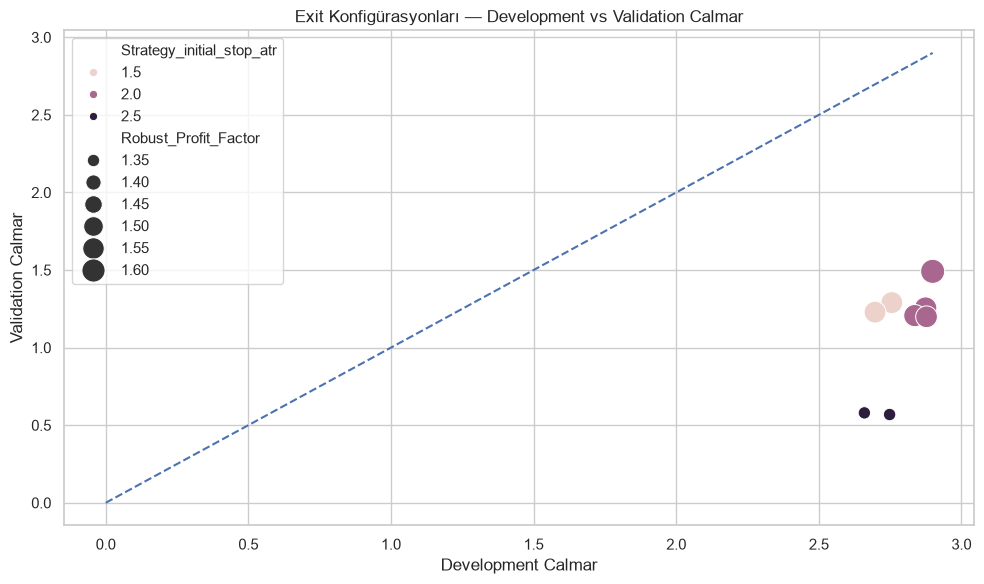

In [8]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=exit_stability,
    x="Calmar_Development",
    y="Calmar_Validation",
    size="Robust_Profit_Factor",
    hue="Strategy_initial_stop_atr",
    sizes=(80, 300),
)

max_axis = max(
    exit_stability["Calmar_Development"].max(),
    exit_stability["Calmar_Validation"].max(),
)

plt.plot(
    [0, max_axis],
    [0, max_axis],
    linestyle="--",
)

plt.title("Exit Konfigürasyonları — Development vs Validation Calmar")
plt.xlabel("Development Calmar")
plt.ylabel("Validation Calmar")
plt.tight_layout()
plt.show()


## 7. Seçim

İlk satır otomatik olarak kesin kazanan değildir. Baseline ile karşılaştır:

- Validation Calmar
- Validation Profit Factor
- Validation drawdown
- Development-validation farkı
- İşlem sayısı

Seçim yapıldıktan sonra yalnızca o konfigürasyon holdout döneminde bir kez çalıştırılır.
